In [370]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [371]:
df = pd.read_csv('AmesHousing.txt', sep='\t')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

In [372]:
df.sample(5)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2078,2079,905426010,20,RL,84.0,12615,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal,243000
108,109,533352170,60,RL,NaN,13517,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,130500
2681,2682,903233220,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,2,2006,WD,Normal,110000
438,439,528120030,20,RL,87.0,10367,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2009,ConLI,Normal,335000
1659,1660,527359080,60,RL,NaN,12384,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,11,2007,WD,Normal,197900


In [373]:
print(df.shape)
print(df.isna().sum())

(2930, 82)
Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64


In [374]:
# df.drop_duplicates(inplace=True)
# df.dropna(inplace=True)

df.dtypes

Order               int64
PID                 int64
MS SubClass         int64
MS Zoning             str
Lot Frontage      float64
                   ...   
Mo Sold             int64
Yr Sold             int64
Sale Type             str
Sale Condition        str
SalePrice           int64
Length: 82, dtype: object

In [375]:
df.dropna(axis=1, inplace=True)
df.drop_duplicates(inplace=True)
print(df.shape)
df.sample(5)

(2930, 55)


,Order,PID,MS SubClass,MS Zoning,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2217,2218,909281020,190,RL,6221,Pave,IR1,Lvl,AllPub,Inside,...,0,0,144,0,0,10,2007,WD,Normal,140000
1546,1547,910202050,30,RM,3636,Pave,Reg,Lvl,AllPub,Inside,...,100,0,0,0,0,1,2008,WD,Normal,55000
2049,2050,905100080,85,RL,11235,Pave,Reg,Lvl,AllPub,Inside,...,88,0,0,0,0,11,2007,WD,Normal,158450
161,162,535450210,50,RL,8064,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,5,2010,WD,Normal,132000
299,300,909455040,120,RM,3907,Pave,IR1,HLS,AllPub,Inside,...,0,0,0,0,0,3,2010,WD,Normal,162500


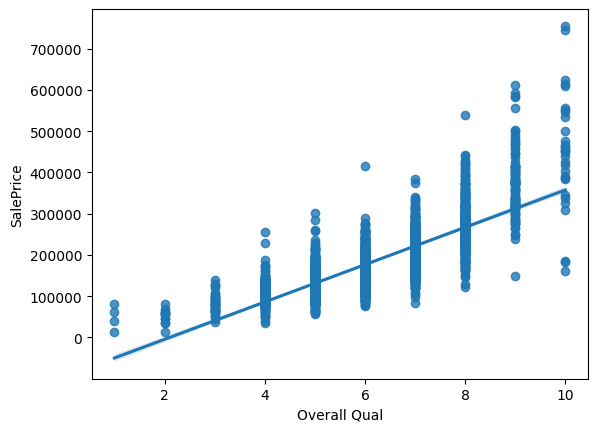

In [376]:
sns.regplot(data=df, x='Overall Qual', y='SalePrice')
plt.show()

In [377]:
# X = df['Overall Qual'].values.reshape(-1, 1)
X = df[['Overall Qual', 'Lot Area']]
Y = df['SalePrice'].values.reshape(-1, 1)

In [378]:
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()
sc_Y = StandardScaler()

X_std = sc_X.fit_transform(X)
Y_std = sc_Y.fit_transform(Y)

In [379]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X_std, Y_std, test_size=0.3)

In [380]:
X_train.mean(axis=0).shape

(2,)

In [381]:
class MySimpleLinearRegression:
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None
    
    def fit(self, X, Y):
        X = X[:, 0]
        Y = Y[:, 0]
        X_mean = X.mean()
        Y_mean = Y.mean()
        self.coef_ = ((X - X_mean) * (Y - Y_mean)).sum() / ((X - X_mean) ** 2).sum()
        self.intercept_ = Y_mean - self.coef_ * X_mean
    
    def predict(self, X):
        return self.intercept_ + self.coef_ * X

# class MyClassifier:


In [382]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
# model2 = MySimpleLinearRegression()

model.fit(X_train, Y_train)
# model2.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 2)","[[0.79,0.18]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[0.01]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[51.09,45.29]"


In [383]:
print(f'model1={model.coef_}, {model.intercept_}')
# print(f'model2={model2.coef_:.4f}, {model2.intercept_:.4f}')

model1=[[0.79196032 0.18189735]], [0.00788248]


In [384]:
Y_pred = model.predict(X_test)
# Y_pred2 = model2.predict(X_test)

# print((Y_pred != Y_pred2).sum())

[Text(0.5, 0, 'Y_test'), Text(0, 0.5, 'Y_pred')]

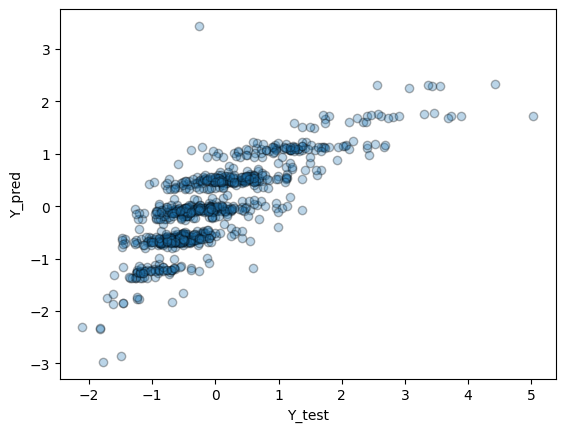

In [385]:
fig, ax = plt.subplots()
ax.scatter(Y_test, Y_pred, alpha=0.3, edgecolors='k')
# ax.scatter(Y_test, Y_pred2, alpha=0.3, edgecolors='k')
ax.set(xlabel='Y_test', ylabel='Y_pred')

In [386]:
from sklearn.metrics import r2_score

r2 = r2_score(Y_test, Y_pred)
print(f'r2={r2:.4f}')

# r2_2 = r2_score(Y_test, Y_pred2)
# print(f'r2={r2_2:.4f}')

r2=0.6625


In [387]:
from sklearn import datasets

iris = datasets.load_iris()
print(type(iris))

<class 'sklearn.utils._bunch.Bunch'>


In [388]:
X, Y = iris.data, iris.target
Y = Y.reshape(-1, 1)

print(X.shape)
print(Y.shape)

(150, 4)
(150, 1)


In [389]:
sc_X = StandardScaler()

X_std = sc_X.fit_transform(X)

In [390]:
X_train, X_test, Y_train, Y_test = train_test_split(X_std, Y)

In [391]:
class MyKNeighborsClassifier:
    def __init__(self, n_neighbors=3):
        self.n_neighbors = n_neighbors
        self.X = None
        self.Y = None
    
    def fit(self, X, Y):
        self.X = X
        self.Y = Y
    
    def predict(self, X):
        X_train = self.X.reshape(1, self.X.shape[0], -1)
        X_test = X.reshape(X.shape[0], 1, -1)
        dist = ((X_train - X_test) ** 2).sum(axis=2)
        nearest_k_idx = dist.argsort(axis=1)[:, :self.n_neighbors]
        nearest_k = self.Y[nearest_k_idx]
        uniques = np.unique(self.Y)
        return uniques[(nearest_k == uniques).sum(axis=1).argmax(axis=1)]

In [392]:
from sklearn import neighbors

model = neighbors.KNeighborsClassifier(n_neighbors=7)
model2 = MyKNeighborsClassifier(n_neighbors=7)

In [393]:
model.fit(X_train, Y_train)
model2.fit(X_train, Y_train)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [394]:
Y_pred = model.predict(X_test)
Y_pred2 = model2.predict(X_test)

In [430]:
from sklearn.metrics import \
    accuracy_score, confusion_matrix, \
        precision_score, recall_score, f1_score

def my_accuracy(Y_test, Y_pred):
    Y_pred = Y_pred[:, 0]
    correct = (Y_pred == Y_test).sum()
    return correct / Y_pred.size

# |               |Actual True|Actual False|
# |Predicted True |    TP     |     FP     |
# |Predicted False|    FN     |     TN     |

# |           |Actual A|Actual B|Actual C|
# |Predicted A|   TP   |    F   |    F   |
# |Predicted B|    F   |   TP   |    F   |
# |Predicted C|    F   |    F   |   TP   |
def my_confusion_matrix(Y_test, Y_pred):
    Y_test = Y_test.reshape(-1, 1)
    Y_pred = Y_pred.reshape(-1, 1)
    classes = np.unique(Y_test)
    tp = Y_test[Y_test == Y_pred]
    tp_by_classes = (tp.reshape(-1, 1) == classes.reshape(1, -1)).sum(axis=0)
    f_actual = Y_test[Y_test != Y_pred]
    f_predicted = Y_pred[Y_test != Y_pred]
    f = np.array([f_actual, f_predicted])  # 2,m
    uniques = np.unique(f, axis=1)         # 2,n
    bidx = (f[:, :, np.newaxis] == uniques[:, np.newaxis, :]) # 2,m,n
    counts = bidx.sum(axis=(1, 0)) // 2 # n

    features = classes.size
    confusion_matrix = np.zeros((features, features), dtype=np.int64)
    np.fill_diagonal(confusion_matrix, tp_by_classes)
    confusion_matrix[uniques[0, :], uniques[1, :]] = counts
    return confusion_matrix

def my_precision(Y_test, Y_pred, average='macro'):
    Y_test = Y_test.reshape(-1, 1)
    Y_pred = Y_pred.reshape(-1, 1)
    classes = np.unique(Y_test)
    t_actual = Y_test[Y_test == Y_pred]
    f_pred = Y_pred[Y_test != Y_pred]
    tp = (t_actual.reshape(-1, 1) == classes.reshape(1, -1)).sum(axis=0)
    fp = (f_pred.reshape(-1, 1) == classes.reshape(1, -1)).sum(axis=0)
    precision = tp / (tp + fp)
    if average == 'macro':
        return precision.mean()
    else:
        return precision

def my_recall(Y_test, Y_pred, average='macro'):
    Y_test = Y_test.reshape(-1, 1)
    Y_pred = Y_pred.reshape(-1, 1)
    classes = np.unique(Y_test)
    t_actual = Y_test[Y_test == Y_pred]
    f_actual = Y_test[Y_test != Y_pred]
    tp = (t_actual.reshape(-1, 1) == classes.reshape(1, -1)).sum(axis=0)
    fn = (f_actual.reshape(-1, 1) == classes.reshape(1, -1)).sum(axis=0)
    recall = tp / (tp + fn)
    if (average == 'macro'):
        return recall.mean()
    else:
        return recall

def print_metrics(Y_test, Y_pred):
    print(f'accuracy={accuracy_score(Y_test, Y_pred):.4f}')
    print(f'confusion_matrix=\n{confusion_matrix(Y_test, Y_pred)}')
    print(f'precision={precision_score(Y_test, Y_pred, average=None)}')
    print(f'recall={recall_score(Y_test, Y_pred, average=None)}')
    print(f'f1={f1_score(Y_test, Y_pred, average=None)}')
    print()
    print(f'precision={precision_score(Y_test, Y_pred, average='macro'):.4f}')
    print(f'recall={recall_score(Y_test, Y_pred, average='macro'):.4f}')
    print(f'f1={f1_score(Y_test, Y_pred, average='macro'):.4f}')

# print('model1=')
# print_metrics(Y_test, Y_pred)
# print('\nmodel2=')
# print_metrics(Y_test, Y_pred2)

print('========confusion matrix=======')
print(confusion_matrix(Y_test, Y_pred))

print('=======my confusion matrix=======')
print(my_confusion_matrix(Y_test, Y_pred2))

print('========precision========')
print(precision_score(Y_test, Y_pred, average=None))
print('=======my precision======')
print(my_precision(Y_test, Y_pred, average=None))

print('========recall========')
print(recall_score(Y_test, Y_pred, average=None))
print('=======my precision======')
print(my_recall(Y_test, Y_pred, average=None))

========confusion matrix=======
[[15  0  0]
 [ 0 14  0]
 [ 0  1  8]]
=======my confusion matrix=======
[[15  0  0]
 [ 0 14  0]
 [ 0  1  8]]
========precision========
[1.         0.93333333 1.        ]
=======my precision======
[1.         0.93333333 1.        ]
========recall========
[1.         1.         0.88888889]
=======my precision======
[1.         1.         0.88888889]


In [396]:
print(np.unique(Y_test))
print(Y_pred2)
print(Y_pred == Y_pred2)

[0 1 2]
[0 0 0 1 1 2 2 0 2 1 2 1 0 1 1 2 1 1 1 1 0 2 0 2 0 1 0 0 0 0 1 2 0 1 1 0 0
 1]
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True]
